# Hotel Booking Demand: Feature Engineering

## 1. PROJE KURULUMU VE VERİ SETİNİN YÜKLENMESİ

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import os
import warnings
 
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
data_path = os.path.join(project_root, "data", "raw","hotel_bookings.csv")

try:
    data = pd.read_csv(data_path)
except FileNotFoundError:            # Hata yönetimi
    print("Error: Data file error")

In [16]:
display(f"Veri setinin ilk hali: {data.shape}")
display(data.head())

'Veri setinin ilk hali: (119390, 32)'

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## 2. VERİ TEMİZLİĞİ VE EKSİK DEĞER YÖNETİMİ

In [17]:
null_df = pd.DataFrame({'Null Values' : data.isnull().sum(), 'Percentage %' : (data.isna().sum() / len(data))*100 }).round(2)
null_df[null_df['Null Values'] > 0]

,Null Values,Percentage %
children,4,0.00
country,488,0.41
agent,16340,13.69
company,112593,94.31


In [18]:
data.drop(['company'], axis=1, inplace=True) # sütunu silmek
data['agent'] = data['agent'].fillna(0) # eksik değerleri sıfır ile doldurmak
data['children'] = data['children'].fillna(0)
data['country'] = data['country'].fillna(data['country'].mode()[0]) # eksik değerleri mod ile doldurmak

# hatalı kayıtları silme

zero_guests = (data['adults'] + data['children'] + data['babies'] == 0)
data = data[~zero_guests]
data.shape

(119210, 31)

## 3. ZAMAN TABANLI ÖZELLİK MÜHENDİSLİĞİ

In [19]:
#  ay isimlerini sayılara çevirme
month_map = {'January':1, 'February':2, 'March':3, 'April':4, 'May':5, 'June':6, 
             'July':7, 'August':8, 'September':9, 'October':10, 'November':11, 'December':12}
data['arrival_date_month_num'] = data['arrival_date_month'].map(month_map)


data['arrival_date'] = pd.to_datetime(data['arrival_date_year'].astype(str) + '-' + 
                                      data['arrival_date_month_num'].astype(str) + '-' + 
                                      data['arrival_date_day_of_month'].astype(str))

#  hafta sonu 
data['is_weekend'] = data['arrival_date'].dt.dayofweek.apply(lambda x: 1 if x in [4, 5] else 0)

# mevsim Türetme
def get_season(month):
    if month in [12, 1, 2]: return 'Winter'
    elif month in [3, 4, 5]: return 'Spring'
    elif month in [6, 7, 8]: return 'Summer'
    else: return 'Autumn'

data['season'] = data['arrival_date_month_num'].apply(get_season)

# tekarar için sin - cos dönüşümü
data['month_sin'] = np.sin(2 * np.pi * data['arrival_date_month_num'] / 12)
data['month_cos'] = np.cos(2 * np.pi * data['arrival_date_month_num'] / 12)

## 4. MÜŞTERİ DAVRANIŞ VE KONAKLAMA ANALİZİ

In [20]:
# toplam geceleme sayısı
data['total_stay'] = data['stays_in_weekend_nights'] + data['stays_in_week_nights']

# rezervasyon Önceliği 
# 0-7: Son Dakika, 8-30: Kısa Vadeli, 31-90: Orta, 90+: Uzun Vadeli
bins = [-1, 7, 30, 90, data['lead_time'].max()]
labels = ['Last Minute', 'Short Term', 'Medium Term', 'Long Term']
data['lead_time_bins'] = pd.cut(data['lead_time'], bins=bins, labels=labels)

# rezervasyon değişikliği 1 evet 0 hayır 
data['booking_changes_flag'] = data['booking_changes'].apply(lambda x: 1 if x > 0 else 0)

# iptal oranı
data['previous_cancel_ratio'] = data['previous_cancellations'] / (data['previous_cancellations'] + data['previous_bookings_not_canceled'] + 1e-5)

# toplam kişi sayısı
data['total_people'] = data['adults'] + data['children'] + data['babies']

# aile mi , çocuk varsa 1 yoksa 0
data['is_family'] = data.apply(lambda x: 1 if (x['children'] > 0) or (x['babies'] > 0) else 0, axis=1)

# tek kişimi yoksa daha fazla mı
data['is_single'] = data.apply(lambda x: 1 if (x['adults'] == 1) and (x['children'] == 0) and (x['babies'] == 0) else 0, axis=1)
data['is_couple'] = data.apply(lambda x: 1 if (x['adults'] == 2) and (x['children'] == 0) and (x['babies'] == 0) else 0, axis=1)

## 6. FİNANSAL METRİKLER VE DÖNÜŞÜMLER

c:\Users\İlyas\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


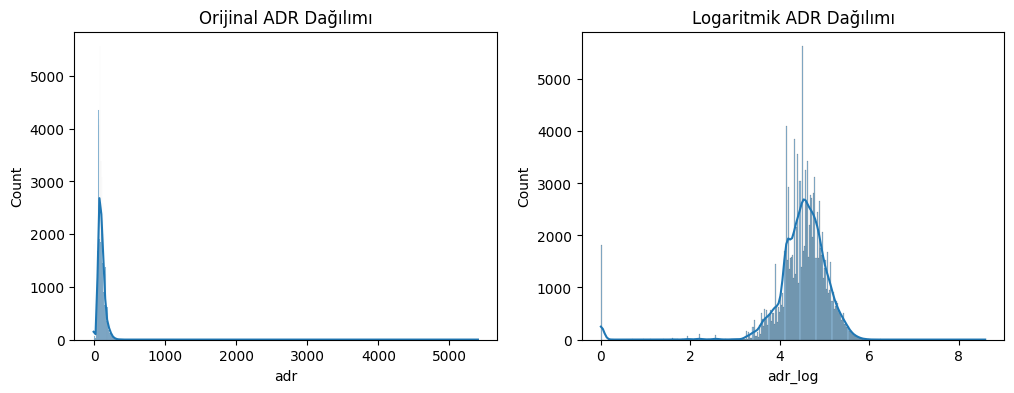

In [21]:
# kişi başına fiyat bebekler dahil değil
data['price_per_person'] = data['adr'] / (data['total_people'] + 0.1)

# toplam gelir
data['total_revenue'] = data['adr'] * data['total_stay']

# log dönüşümü
data['adr_log'] = np.log1p(data['adr'])

# log dönüşümü etkisi
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.histplot(data['adr'], kde=True).set_title('Orijinal ADR Dağılımı')
plt.subplot(1,2,2)
sns.histplot(data['adr_log'], kde=True).set_title('Logaritmik ADR Dağılımı')
plt.show()

## 7. KATEGORİK VERİ VE ENCODING STRATEJİLERİ

In [22]:
# istediği oda verildimi
 
data['room_type_match'] = (data['reserved_room_type'] == data['assigned_room_type']).astype(int)

# rezervasyonu acente ile mi yapmış 
data['agent_binary'] = data['agent'].apply(lambda x: 1 if x != 0 else 0)

 
top_10_countries = data['country'].value_counts().nlargest(10).index
data['country_segment'] = data['country'].apply(lambda x: x if x in top_10_countries else 'Other')

 
data['missing_country_flag'] = (data['country'] == data['country'].mode()[0]).astype(int) 

## 8. AYKIRI DEĞER YÖNETİMİ (OUTLIER CLIPPING)

In [23]:
# outlier clipping fonksiyonu
def outlier_thresholds(dataframe, variable, lower_quantile=0.01, upper_quantile=0.99):
    quants = dataframe[variable].quantile([lower_quantile, upper_quantile])
    return quants.iloc[0], quants.iloc[1]

# outlier clipping uygulaması
def replace_with_thresholds(dataframe, variable):
    low_limit, up_limit = outlier_thresholds(dataframe, variable)
    
    dataframe.loc[(dataframe[variable] < low_limit), variable] = low_limit
    dataframe.loc[(dataframe[variable] > up_limit), variable] = up_limit
 
replace_with_thresholds(data, 'adr')
replace_with_thresholds(data, 'lead_time')
replace_with_thresholds(data, 'total_stay')

## 9. GELİŞMİŞ EDA VE GÖRSELLEŞTİRME

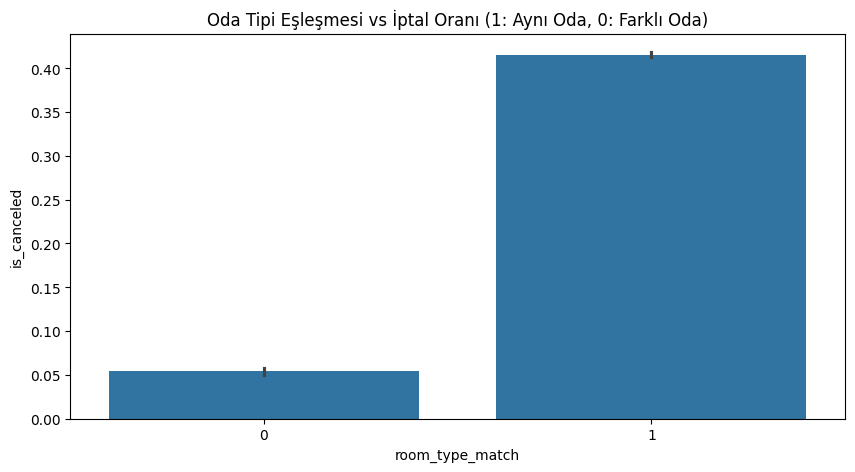

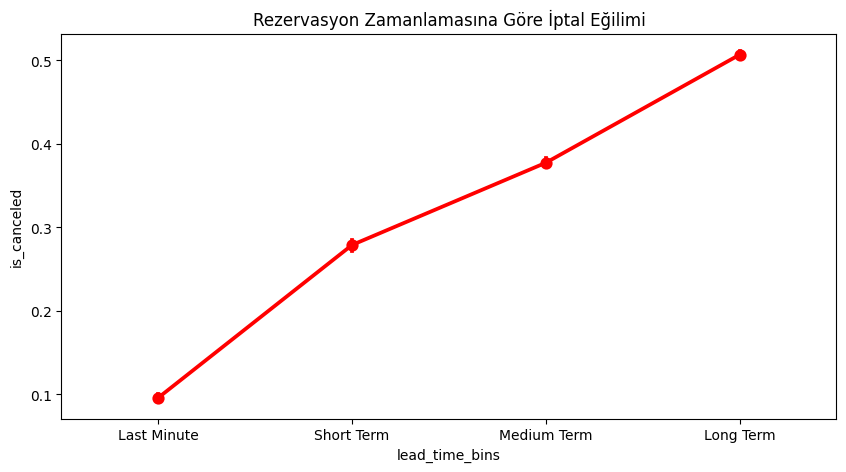

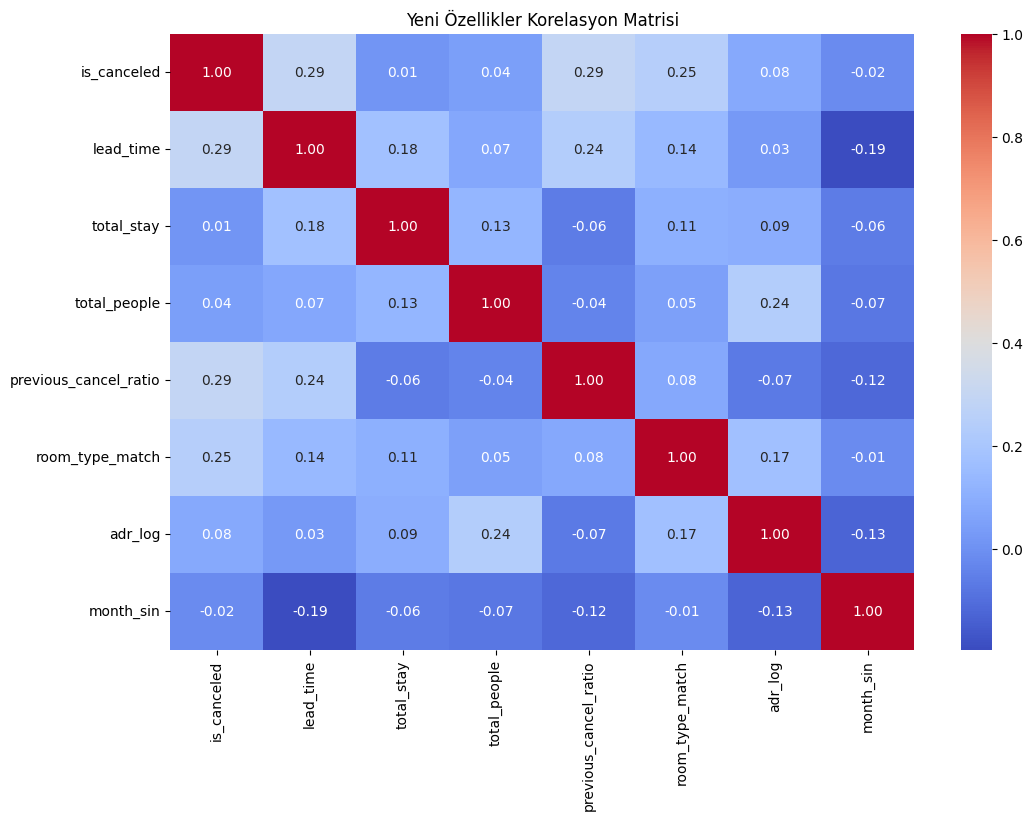

In [24]:
plt.figure(figsize=(10, 5))
sns.barplot(x='room_type_match', y='is_canceled', data=data)
plt.title('Oda Tipi Eşleşmesi vs İptal Oranı (1: Aynı Oda, 0: Farklı Oda)')
plt.show()
 
plt.figure(figsize=(10, 5))
sns.pointplot(x='lead_time_bins', y='is_canceled', data=data, color='red')
plt.title('Rezervasyon Zamanlamasına Göre İptal Eğilimi')
plt.show()


cols_to_corr = ['is_canceled', 'lead_time', 'total_stay', 'total_people', 
                'previous_cancel_ratio', 'room_type_match', 'adr_log', 'month_sin']
corr_matrix = data[cols_to_corr].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Yeni Özellikler Korelasyon Matrisi')
plt.show()

## 10. SONUÇ VE VERİ DIŞA AKTARIMI

In [25]:
# veriyi kaydetme
output_path = os.path.join(project_root, "data", "processed", "hotel_bookings_featured.csv")
os.makedirs(os.path.dirname(output_path), exist_ok=True)
data.to_csv(output_path, index=False)